# TT-27 — RNN / LSTM / GRU: Dự báo lưu lượng giao thông theo giờ

In [1]:
!pip -q install xgboost
import os, glob, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

warnings.filterwarnings("ignore")
tf.random.set_seed(42); np.random.seed(42)
for p in ["reports", "models"]: os.makedirs(p, exist_ok=True)

In [2]:
DATA_PATH = "D:\TT_ML\TT-27-RNN-LSTM_Linh\data\Metro_Interstate_Traffic_Volume.csv"
import zipfile, urllib.request
from urllib.parse import urlparse, unquote

def resolve_data(path):
    path = str(path).strip(); os.makedirs("data", exist_ok=True)
    if path.startswith(("http://", "https://", "file://")):
        local = os.path.join("data", os.path.basename(unquote(urlparse(path).path)) or "data.csv")
        if not os.path.exists(local):
            req = urllib.request.Request(path, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req) as r, open(local, "wb") as f: f.write(r.read())
        path = local
    if path.lower().endswith(".zip"):
        with zipfile.ZipFile(path) as z:
            z.extractall("data")
            inner = [n for n in z.namelist() if n.lower().endswith((".csv", ".csv.gz"))]
        path = os.path.join("data", inner[0])
    return path

raw = pd.read_csv(resolve_data(DATA_PATH))          # pandas tự giải nén .gz
raw["date_time"] = pd.to_datetime(raw["date_time"])
print(raw.shape); raw.head()

(48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


## Bước 1 — Làm sạch (xử lý 3 trong 4 vấn đề dữ liệu)

In [3]:
print("Dòng trùng date_time:", raw["date_time"].duplicated().sum())
print("temp==0:", (raw.temp == 0).sum(), "| rain_1h>100:", (raw.rain_1h > 100).sum())

# pandas bản mới đọc chuỗi "None" thành NaN -> phải coi CẢ NaN lẫn "None" là "không phải ngày lễ"
raw["holiday_flag"] = (raw["holiday"].notna() & (raw["holiday"] != "None")).astype(int)
df = (raw.sort_values("date_time")
         .groupby("date_time")
         .agg(traffic_volume=("traffic_volume", "first"), temp=("temp", "first"),
              rain_1h=("rain_1h", "first"), snow_1h=("snow_1h", "first"),
              clouds_all=("clouds_all", "first"), weather_main=("weather_main", "first"),
              holiday_flag=("holiday_flag", "max")))

# ngoại lai phi lý -> NaN
df.loc[df["temp"] < 200, "temp"] = np.nan          # Kelvin: <200K (~ -73°C) là vô lý
df.loc[df["rain_1h"] > 100, "rain_1h"] = np.nan    # >100 mm/giờ là vô lý

# lan cờ ngày lễ ra cả ngày
hol_by_date = df.groupby(df.index.normalize())["holiday_flag"].max()
print("Số ngày lễ:", int(hol_by_date.sum()), "| Số dòng:", len(df))

Dòng trùng date_time: 7629
temp==0: 10 | rain_1h>100: 1
Số ngày lễ: 53 | Số dòng: 40575


## Bước 2 — Xử lý lỗ hổng thời gian (vấn đề số 1)

`reindex` theo lưới giờ đầy đủ để **lộ ra các giờ bị thiếu**. Chiến lược:
- **Lỗ ngắn (≤ 6 giờ):** nội suy tuyến tính + gắn **cột cờ `imputed`** để mô hình biết đó là số ước lượng.
- **Lỗ dài (> 6 giờ):** *không bịa dữ liệu*. Để trống và **cắt chuỗi thành nhiều đoạn liên tục**; cửa sổ trượt chỉ được tạo **bên trong một đoạn**, không bao giờ băng qua lỗ hổng (tránh cửa sổ chứa 2 thời điểm cách nhau nhiều ngày).

In [4]:
full_idx = pd.date_range(df.index.min(), df.index.max(), freq="h")
h = df.reindex(full_idx)
print(f"Lưới giờ đầy đủ: {len(full_idx):,} | có dữ liệu: {len(df):,} | thiếu: {len(full_idx)-len(df):,}")

h["imputed"] = h["traffic_volume"].isna().astype(int)
h["is_holiday"] = h.index.normalize().map(hol_by_date).fillna(0)

num_cols = ["traffic_volume", "temp", "rain_1h", "snow_1h", "clouds_all"]
MAX_GAP = 6

# độ dài của từng "vệt" NaN liên tiếp ở traffic
isna = h["traffic_volume"].isna()
run_id_gap = (isna != isna.shift()).cumsum()
run_len = isna.groupby(run_id_gap).transform("sum")
short = isna & (run_len <= MAX_GAP)                 # chỉ lấp lỗ NGẮN

interp = h[num_cols].interpolate(limit_area="inside")
for c in num_cols:
    h.loc[short, c] = interp.loc[short, c]

# thời tiết rời rạc (NaN do lọc ngoại lai): nội suy rồi ffill/bfill
for c in ["temp", "rain_1h", "snow_1h", "clouds_all"]:
    h[c] = h[c].interpolate(limit_area="inside").ffill().bfill()
h["weather_main"] = h["weather_main"].ffill().bfill()

gaps = run_len[isna & (run_len > MAX_GAP)]
n_long = gaps.groupby(run_id_gap[gaps.index]).first()
print(f"Lỗ ngắn được nội suy: {int(short.sum())} giờ | Số lỗ DÀI: {len(n_long)} | dài nhất: {int(n_long.max()) if len(n_long) else 0} giờ")

Lưới giờ đầy đủ: 52,551 | có dữ liệu: 40,575 | thiếu: 11,976
Lỗ ngắn được nội suy: 3048 giờ | Số lỗ DÀI: 76 | dài nhất: 7386 giờ


## Bước 3 — EDA: lưu lượng theo giờ / thứ / tháng
Chỉ dùng giờ có dữ liệu thật (`imputed == 0`). Ta kỳ vọng thấy **2 đỉnh giờ cao điểm** và **cuối tuần khác hẳn ngày thường**.

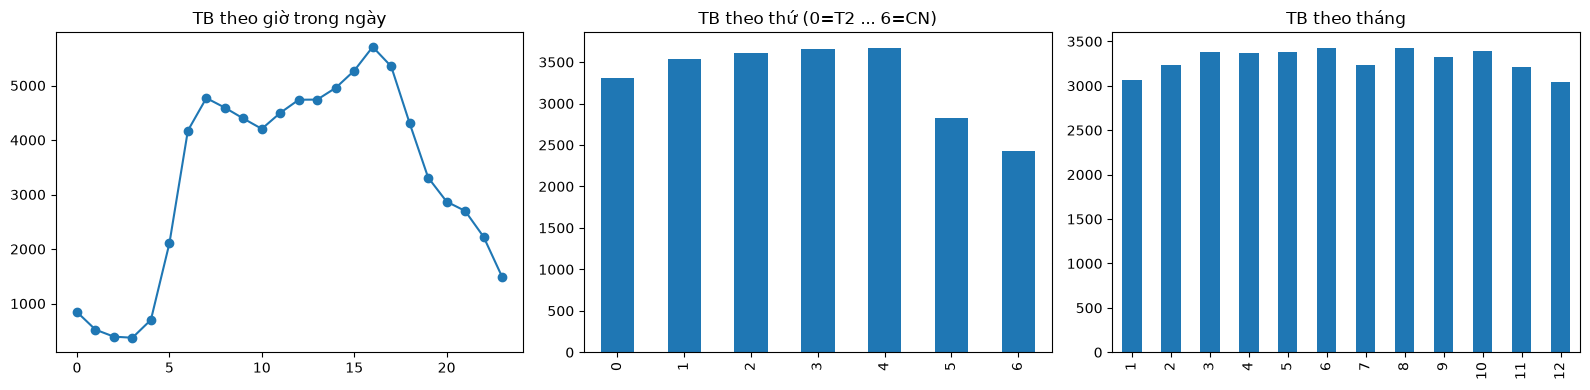

In [5]:
real = h[(h.imputed == 0)]
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
real.groupby(real.index.hour)["traffic_volume"].mean().plot(ax=ax[0], marker="o"); ax[0].set_title("TB theo giờ trong ngày")
real.groupby(real.index.dayofweek)["traffic_volume"].mean().plot(ax=ax[1], kind="bar"); ax[1].set_title("TB theo thứ (0=T2 ... 6=CN)")
real.groupby(real.index.month)["traffic_volume"].mean().plot(ax=ax[2], kind="bar"); ax[2].set_title("TB theo tháng")
plt.tight_layout(); plt.savefig("reports/eda_theo_gio.png", dpi=130); plt.show()

## Bước 4 — Đặc trưng
- **sin/cos cho giờ và thứ:** giờ 23 và giờ 0 thực ra *liền kề*; nếu để số 23 → 0 mô hình thấy "xa nhau". Mã hoá vòng tròn giải quyết việc đó.
- **`is_holiday`** (đã lan cả ngày), **one-hot `weather_main`**, **`rain_1h` → log1p** (rất lệch phải), cờ **`imputed`**.
- Giữ lại `traffic_volume` quá khứ làm một đặc trưng đầu vào (LSTM cần "nhìn" lịch sử lưu lượng).

Chỉ giữ những giờ **có dữ liệu** (sau bước 2) — các lỗ dài tự động bị loại.

In [6]:
d = h[h["traffic_volume"].notna()].copy()
hour, dow = d.index.hour, d.index.dayofweek
d["hour_sin"], d["hour_cos"] = np.sin(2*np.pi*hour/24), np.cos(2*np.pi*hour/24)
d["dow_sin"],  d["dow_cos"]  = np.sin(2*np.pi*dow/7),  np.cos(2*np.pi*dow/7)
d["rain_log"] = np.log1p(d["rain_1h"])
wm = pd.get_dummies(d["weather_main"], prefix="w").astype(float)
d = pd.concat([d, wm], axis=1)

cont_cols = ["traffic_volume", "temp", "rain_log", "snow_1h", "clouds_all"]
feature_cols = cont_cols + ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_holiday", "imputed"] + list(wm.columns)
print(len(feature_cols), "đặc trưng:", feature_cols)

22 đặc trưng: ['traffic_volume', 'temp', 'rain_log', 'snow_1h', 'clouds_all', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_holiday', 'imputed', 'w_Clear', 'w_Clouds', 'w_Drizzle', 'w_Fog', 'w_Haze', 'w_Mist', 'w_Rain', 'w_Smoke', 'w_Snow', 'w_Squall', 'w_Thunderstorm']


## Bước 5 — Chia theo thời gian (70 / 15 / 15) + scaler chống rò rỉ

Nguyên tắc chống rò rỉ (đề mục 4.3):
1. **Chia theo thời gian**, không shuffle khi chia (train = quá khứ xa nhất, test = gần nhất). Được shuffle các *cửa sổ* trong lúc train.
2. **Scaler chỉ `fit` trên train**, rồi `transform` cho val/test.
3. Cửa sổ đầu vào chỉ chứa quá khứ, và **cửa sổ không băng qua ranh giới split hay lỗ hổng**.

In [7]:
n = len(d); i70, i85 = int(n*0.70), int(n*0.85)
d["split"] = ["train"]*i70 + ["val"]*(i85-i70) + ["test"]*(n-i85)
for s in ["train", "val", "test"]:
    sub = d[d.split == s]; print(f"{s:5s}: {len(sub):6d} giờ  {sub.index.min().date()} -> {sub.index.max().date()}")

scaler = StandardScaler().fit(d.loc[d.split == "train", cont_cols])   # CHỈ fit trên train
d_s = d.copy()
d_s[cont_cols] = scaler.transform(d[cont_cols])
mu, sd = scaler.mean_[0], scaler.scale_[0]          # để đổi dự báo về đơn vị "xe/giờ"

Fv = d_s[feature_cols].values.astype("float32")
yv = d_s["traffic_volume"].values.astype("float32")
split_arr = d["split"].values
run_id = (d.index.to_series().diff() != pd.Timedelta("1h")).cumsum().values   # mỗi đoạn liên tục 1 id

def tao_chuoi(X, y, do_dai=24, buoc_du_bao=1):
    """do_dai = số giờ quá khứ; nhãn nằm SAU cửa sổ buoc_du_bao giờ."""
    Xs, ys = [], []
    for i in range(len(X) - do_dai - buoc_du_bao + 1):
        Xs.append(X[i:i+do_dai])
        ys.append(y[i+do_dai+buoc_du_bao-1])
    return np.array(Xs), np.array(ys)

def make_dataset(window=24, horizon=1):
    """Tạo cửa sổ RIÊNG cho từng (đoạn liên tục x split) -> không băng qua lỗ hổng/ranh giới."""
    bk = {s: {"X": [], "y": [], "t0": []} for s in ["train", "val", "test"]}
    key = np.char.add(run_id.astype(str), np.char.add("_", split_arr.astype(str)))
    for k in pd.unique(key):
        idx = np.where(key == k)[0]
        if len(idx) < window + horizon: continue
        Xs, ys = tao_chuoi(Fv[idx], yv[idx], window, horizon)
        t0 = d.index[idx][window-1 : window-1+len(ys)]        # thời điểm CUỐI của cửa sổ (giờ "hiện tại")
        s = k.split("_")[1]
        bk[s]["X"].append(Xs); bk[s]["y"].append(ys); bk[s]["t0"].append(t0.values)
    return {s: {"X": np.concatenate(b["X"]), "y": np.concatenate(b["y"]),
                "t0": pd.DatetimeIndex(np.concatenate(b["t0"]))} for s, b in bk.items()}

demo = make_dataset(24, 1)
print({s: v["X"].shape for s, v in demo.items()})    # (số mẫu, 24, số đặc trưng) đúng định dạng LSTM

train:  30536 giờ  2012-10-02 -> 2017-04-03
val  :   6543 giờ  2017-04-03 -> 2018-01-01
test :   6544 giờ  2018-01-01 -> 2018-09-30
{'train': (29484, 24, 22), 'val': (6495, 24, 22), 'test': (6520, 24, 22)}


## Bước 6 — Baseline bắt buộc: Naive & Seasonal Naive

- **Naive:** giờ này = *cùng giờ hôm qua* (`T − 24h`)
- **Seasonal naive:** giờ này = *cùng giờ tuần trước* (`T − 168h`) → rất mạnh vì giao thông có chu kỳ tuần.

Để **so sánh công bằng**, mọi mô hình được chấm trên **cùng một tập thời điểm test** (`COMMON`: những giờ mà cả 2 baseline đều có giá trị và cửa sổ 48h đều hợp lệ).

In [8]:
sr = h["traffic_volume"]
def baseline_vals(T):
    T = pd.DatetimeIndex(T)
    return (sr.reindex(T - pd.Timedelta(hours=24)).values,
            sr.reindex(T - pd.Timedelta(hours=168)).values)

def common_targets(window, horizon):
    ds = make_dataset(window, horizon)["test"]
    T = ds["t0"] + pd.Timedelta(hours=horizon)
    b24, b168 = baseline_vals(T)
    return T[~np.isnan(b24) & ~np.isnan(b168)]

def mae_on(T, y_true, y_pred, common):
    m = pd.DatetimeIndex(T).isin(common)
    return float(np.mean(np.abs(y_true[m] - y_pred[m])))

COMMON = common_targets(48, 1)          # tập giao của mọi cửa sổ 6/12/24/48
ds24 = make_dataset(24, 1)["test"]
T24 = ds24["t0"] + pd.Timedelta(hours=1)
y24 = ds24["y"] * sd + mu
b24, b168 = baseline_vals(T24)

mae_naive = mae_on(T24, y24, b24, COMMON)
mae_seasonal = mae_on(T24, y24, b168, COMMON)
print(f"Số giờ test dùng để so sánh: {len(COMMON)}")
print(f"Naive (hôm qua)         MAE = {mae_naive:7.1f} xe/giờ")
print(f"Seasonal naive (tuần trước) MAE = {mae_seasonal:7.1f} xe/giờ")

Số giờ test dùng để so sánh: 6496
Naive (hôm qua)         MAE =   564.2 xe/giờ
Seasonal naive (tuần trước) MAE =   338.0 xe/giờ


## Bước 7 — Baseline cây: XGBoost + lag features
Cho mỗi thời điểm "hiện tại" `t0`, XGBoost nhận: các **lag** lưu lượng (1, 2, 3, 6, 12, 24, 48 giờ trước), **lag mùa vụ của chính giờ cần dự báo** (`T-24h`, `T-168h`), lịch của giờ đích (giờ, thứ, ngày lễ) và thời tiết hiện tại. Toàn bộ chỉ dùng thông tin **≤ t0** (lịch là thông tin biết trước, không phải rò rỉ).

In [9]:
def xgb_frame(horizon):
    X = pd.DataFrame(index=h.index)                      # index = t0
    tv = h["traffic_volume"]
    for k in [0, 1, 2, 3, 6, 12, 24, 48]:
        X[f"lag_{k}"] = tv.shift(k)
    X["seas_day"]  = tv.shift(24 - horizon)  if horizon <= 24  else np.nan   # = giá trị tại T-24h
    X["seas_week"] = tv.shift(168 - horizon)                                   # = giá trị tại T-168h
    T = h.index + pd.Timedelta(hours=horizon)
    X["hour_sin"], X["hour_cos"] = np.sin(2*np.pi*T.hour/24), np.cos(2*np.pi*T.hour/24)
    X["dow"] = T.dayofweek
    X["hol_T"] = pd.Series(h["is_holiday"].values, index=h.index).shift(-horizon)
    for c in ["temp", "rain_1h", "snow_1h", "clouds_all"]:
        X[c] = h[c]
    y = tv.shift(-horizon)
    return X, y

def run_xgb(horizon, test_t0):
    X, y = xgb_frame(horizon)
    Tt = X.index + pd.Timedelta(hours=horizon)
    spl = d["split"].reindex(Tt).values
    ok = y.notna().values
    tr, va = (spl == "train") & ok, (spl == "val") & ok
    t = time.time()
    m = xgb.XGBRegressor(n_estimators=800, learning_rate=0.05, max_depth=6, subsample=0.8,
                         colsample_bytree=0.8, early_stopping_rounds=30, eval_metric="mae", n_jobs=-1)
    m.fit(X[tr], y[tr], eval_set=[(X[va], y[va])], verbose=False)
    dt = time.time() - t
    return m.predict(X.loc[test_t0]), dt

xgb_pred24, xgb_time = run_xgb(1, ds24["t0"])
mae_xgb = mae_on(T24, y24, xgb_pred24, COMMON)
print(f"XGBoost + lag  MAE = {mae_xgb:.1f} xe/giờ | thời gian train {xgb_time:.1f}s")

XGBoost + lag  MAE = 143.1 xe/giờ | thời gian train 2.2s


## Bước 8 — SimpleRNN → LSTM → GRU (cùng kiến trúc, cùng siêu tham số)
Cùng cấu trúc `64 → Dropout(0.2) → 32 → Dropout(0.2) → Dense(1)`, chỉ đổi loại tầng hồi quy, để so sánh công bằng.
- Tầng đầu `return_sequences=True` để chuyển **cả chuỗi** sang tầng sau; tầng cuối `False` chỉ lấy trạng thái cuối.
- `Dense(1)` **không activation** (bài toán hồi quy — activation sẽ chặn đầu ra).
- `EarlyStopping` theo `val_loss` (patience 5, khôi phục trọng số tốt nhất) để chống overfit.
- Nhãn đã chuẩn hoá → dự báo được nhân lại `sd`, cộng `mu` để chấm bằng **xe/giờ**.


                    Mô hình Tham số  Thời gian train (s) Epoch Val MAE  Test MAE
                  SimpleRNN    8705                 38.3    23   181.3     172.5
                       LSTM   34721                136.1    39   159.2     156.4
                        GRU   26337                160.0    40   161.4     158.1
            Naive (hôm qua)       -                  0.0     -       -     564.2
Seasonal naive (tuần trước)       -                  0.0     -       -     338.0
              XGBoost + lag       -                  2.2     -       -     143.1


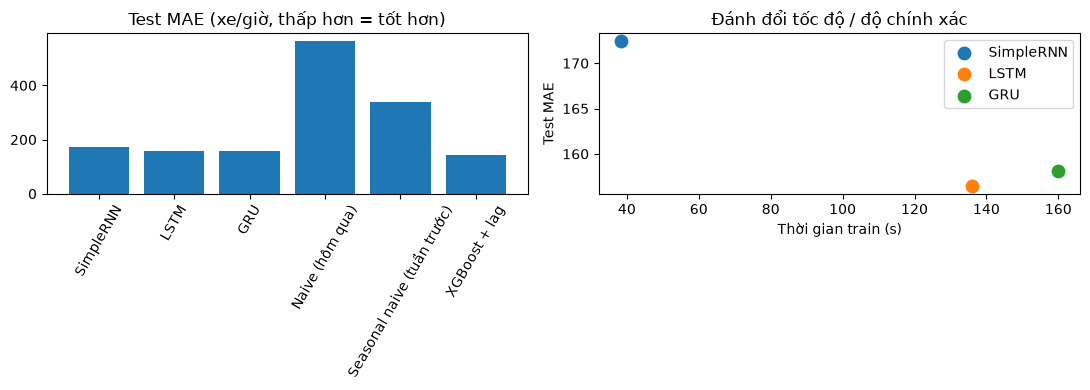

In [10]:
def build_model(kind, window, n_features):
    Rnn = {"SimpleRNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[kind]
    m = tf.keras.Sequential([
        layers.Input(shape=(window, n_features)),
        Rnn(64, return_sequences=True), layers.Dropout(0.2),
        Rnn(32),                        layers.Dropout(0.2),
        layers.Dense(1),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return m

def train_eval(kind, window=24, horizon=1, common=None, epochs=40):
    ds = make_dataset(window, horizon)
    tf.keras.backend.clear_session(); tf.random.set_seed(42)
    m = build_model(kind, window, len(feature_cols))
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    t = time.time()
    hist = m.fit(ds["train"]["X"], ds["train"]["y"], validation_data=(ds["val"]["X"], ds["val"]["y"]),
                 epochs=epochs, batch_size=128, shuffle=True, callbacks=[es], verbose=0)
    dt = time.time() - t
    te = ds["test"]
    pred = m.predict(te["X"], verbose=0).ravel() * sd + mu
    y_true = te["y"] * sd + mu
    T = te["t0"] + pd.Timedelta(hours=horizon)
    return dict(kind=kind, window=window, horizon=horizon, model=m, pred=pred, y=y_true, T=T,
                params=m.count_params(), time=dt, epochs=len(hist.history["loss"]),
                val_mae=min(hist.history["val_mae"]) * sd,
                test_mae=mae_on(T, y_true, pred, common))

results = {k: train_eval(k, 24, 1, COMMON) for k in ["SimpleRNN", "LSTM", "GRU"]}
tab = pd.DataFrame([{"Mô hình": k, "Tham số": r["params"], "Thời gian train (s)": round(r["time"], 1),
                     "Epoch": r["epochs"], "Val MAE": round(r["val_mae"], 1), "Test MAE": round(r["test_mae"], 1)}
                    for k, r in results.items()])
tab.loc[len(tab)] = ["Naive (hôm qua)", "-", 0, "-", "-", round(mae_naive, 1)]
tab.loc[len(tab)] = ["Seasonal naive (tuần trước)", "-", 0, "-", "-", round(mae_seasonal, 1)]
tab.loc[len(tab)] = ["XGBoost + lag", "-", round(xgb_time, 1), "-", "-", round(mae_xgb, 1)]
print(tab.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(tab["Mô hình"], tab["Test MAE"]); ax[0].set_title("Test MAE (xe/giờ, thấp hơn = tốt hơn)"); ax[0].tick_params(axis="x", rotation=60)
for k, r in results.items(): ax[1].scatter(r["time"], r["test_mae"], s=80, label=k)
ax[1].set_xlabel("Thời gian train (s)"); ax[1].set_ylabel("Test MAE"); ax[1].legend(); ax[1].set_title("Đánh đổi tốc độ / độ chính xác")
plt.tight_layout(); plt.savefig("reports/rnn_lstm_gru.png", dpi=130); plt.show()

## Bước 9 — Khảo sát độ dài cửa sổ: 6 / 12 / 24 / 48 giờ
Cửa sổ dài cho mô hình nhiều ngữ cảnh hơn nhưng train chậm hơn và dễ nhiễu. Đề cảnh báo cửa sổ 168h thường không tốt hơn — ta khảo sát đến 48h.

 Cửa sổ (giờ)  Test MAE  Thời gian train (s)
            6     155.2                 41.9
           12     152.6                 84.8
           24     156.4                136.1
           48     162.5                264.5


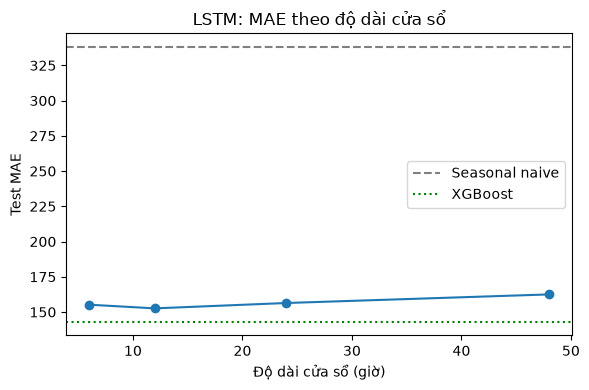

In [11]:
win_res = {w: (results["LSTM"] if w == 24 else train_eval("LSTM", w, 1, COMMON)) for w in [6, 12, 24, 48]}
wt = pd.DataFrame([{"Cửa sổ (giờ)": w, "Test MAE": round(r["test_mae"], 1), "Thời gian train (s)": round(r["time"], 1)}
                   for w, r in win_res.items()])
print(wt.to_string(index=False))
plt.figure(figsize=(6, 4)); plt.plot(wt["Cửa sổ (giờ)"], wt["Test MAE"], marker="o")
plt.axhline(mae_seasonal, ls="--", c="gray", label="Seasonal naive"); plt.axhline(mae_xgb, ls=":", c="green", label="XGBoost")
plt.xlabel("Độ dài cửa sổ (giờ)"); plt.ylabel("Test MAE"); plt.legend(); plt.title("LSTM: MAE theo độ dài cửa sổ")
import os
os.makedirs("reports", exist_ok=True)
plt.tight_layout(); plt.savefig("reports/do_dai_cua_so.png", dpi=130); plt.show()

## Bước 10 — Dự báo vs thực tế trên 1 tuần cuối của tập test

Cửa sổ tốt nhất theo val: 12 giờ


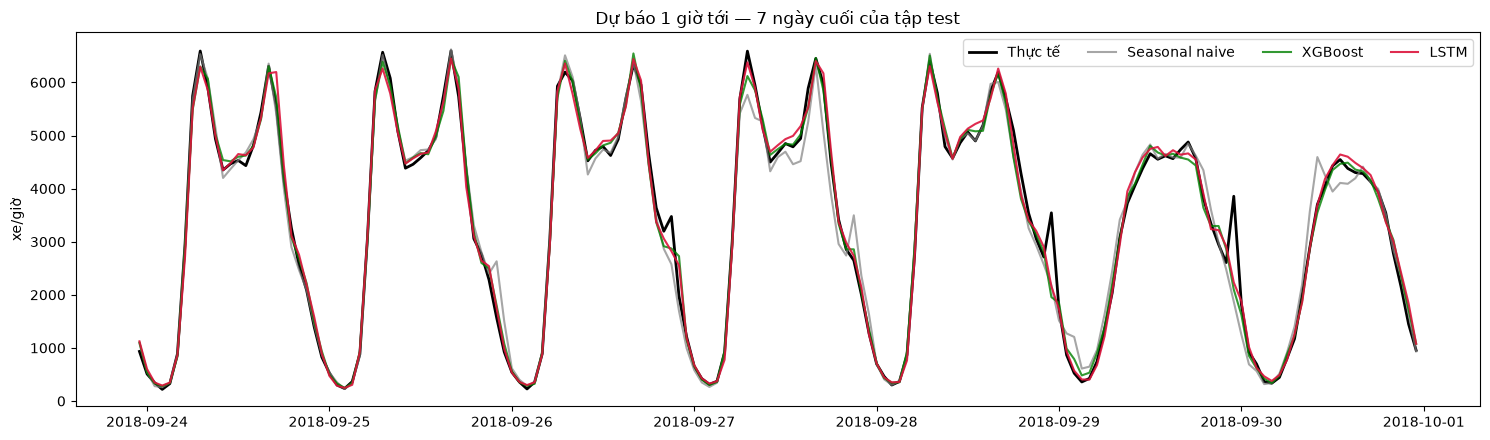

In [12]:
best = min(win_res.values(), key=lambda r: r["val_mae"])       # chọn theo VAL, không nhìn test
print("Cửa sổ tốt nhất theo val:", best["window"], "giờ")
lstm = results["LSTM"]
s_act = pd.Series(lstm["y"], index=lstm["T"])
s_lstm = pd.Series(lstm["pred"], index=lstm["T"])
s_xgb = pd.Series(xgb_pred24, index=lstm["T"])
s_seas = pd.Series(b168, index=lstm["T"])
end = s_act.index.max(); sel = s_act.index >= end - pd.Timedelta(days=7)
plt.figure(figsize=(15, 4.5))
plt.plot(s_act[sel], label="Thực tế", c="black", lw=2)
plt.plot(s_seas[sel], label="Seasonal naive", c="gray", alpha=.7)
plt.plot(s_xgb[sel], label="XGBoost", c="green", alpha=.8)
plt.plot(s_lstm[sel], label="LSTM", c="crimson", alpha=.9)
plt.title("Dự báo 1 giờ tới — 7 ngày cuối của tập test"); plt.ylabel("xe/giờ"); plt.legend(ncol=4)
plt.tight_layout(); plt.savefig("reports/du_bao_vs_thuc_te.png", dpi=130); plt.show()
lstm["model"].save("models/lstm_traffic.keras")

## Bước 11 — Dự báo nhiều bước: 1h / 3h / 6h tới
Dự báo càng xa càng khó nên MAE phải **tăng dần**. Seasonal naive *không phụ thuộc* horizon (luôn nhìn tuần trước) nên là "mốc" để xem LSTM còn thắng được ở horizon xa hay không.

In [13]:
rows = []
for hz in [1, 3, 6]:
    com = common_targets(24, hz)
    r = train_eval("LSTM", 24, hz, com)
    ds_h = make_dataset(24, hz)["test"]
    xp, _ = run_xgb(hz, ds_h["t0"])
    _, bw = baseline_vals(r["T"])
    rows.append({"Horizon (giờ)": hz, "LSTM MAE": round(r["test_mae"], 1),
                 "XGBoost MAE": round(mae_on(r["T"], r["y"], xp, com), 1),
                 "Seasonal naive MAE": round(mae_on(r["T"], r["y"], bw, com), 1)})
    if hz == 1: lstm_h1 = r
mh = pd.DataFrame(rows); print(mh.to_string(index=False))

 Horizon (giờ)  LSTM MAE  XGBoost MAE  Seasonal naive MAE
             1     166.2        143.2               338.4
             3     232.0        188.1               338.0
             6     240.9        202.8               338.0


## Bước 12 — Phân tích lỗi: sai nhiều nhất vào giờ nào, ngày nào?

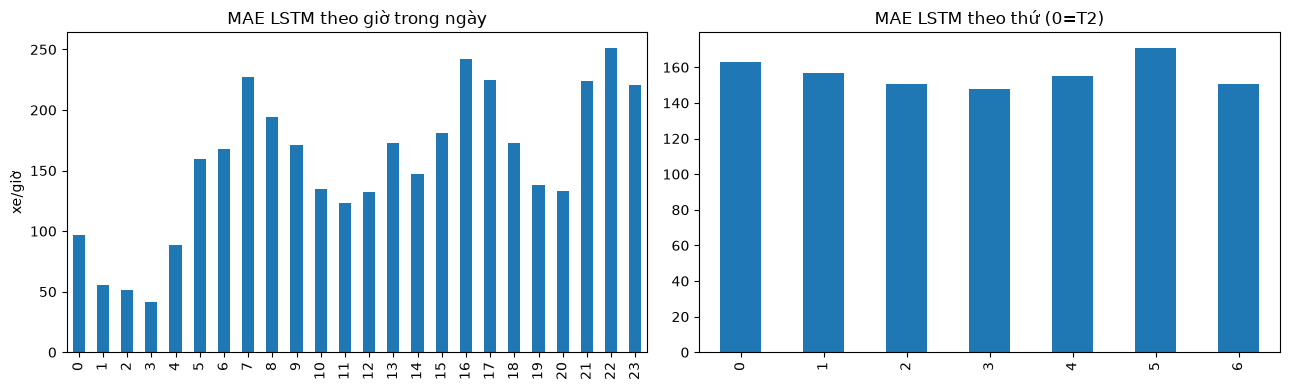

Giờ sai nhiều nhất: 22 giờ (MAE 252)
10 ngày sai nhiều nhất:
2018-03-24    437.0
2018-01-22    384.0
2018-03-05    366.0
2018-04-14    336.0
2018-05-21    329.0
2018-01-17    325.0
2018-04-03    296.0
2018-01-04    275.0
2018-09-20    261.0
2018-01-11    259.0


In [14]:
err = pd.DataFrame({"abs_err": np.abs(lstm["y"] - lstm["pred"])}, index=lstm["T"])
err = err[err.index.isin(COMMON)]
by_hour = err.groupby(err.index.hour)["abs_err"].mean()
by_dow = err.groupby(err.index.dayofweek)["abs_err"].mean()
by_day = err.groupby(err.index.date)["abs_err"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
by_hour.plot(kind="bar", ax=ax[0]); ax[0].set_title("MAE LSTM theo giờ trong ngày"); ax[0].set_ylabel("xe/giờ")
by_dow.plot(kind="bar", ax=ax[1]); ax[1].set_title("MAE LSTM theo thứ (0=T2)")
plt.tight_layout(); plt.savefig("reports/phan_tich_loi.png", dpi=130); plt.show()
print("Giờ sai nhiều nhất:", by_hour.idxmax(), "giờ (MAE %.0f)" % by_hour.max())
print("10 ngày sai nhiều nhất:"); print(by_day.head(10).round(0).to_string())

## Kết luận 
Đề yêu cầu: **LSTM phải thắng seasonal naive**; nếu XGBoost tương đương mà nhanh hơn nhiều thì phải ghi nhận điều đó.

In [15]:
l = results["LSTM"]
print(f"LSTM {l['test_mae']:.0f} | Seasonal naive {mae_seasonal:.0f} | XGBoost {mae_xgb:.0f} | Naive {mae_naive:.0f}  (MAE, xe/giờ)")
if l["test_mae"] < mae_seasonal:
    print(" LSTM thắng seasonal naive -> deep learning có giá trị.")
else:
    print(" LSTM KHÔNG thắng seasonal naive -> kết luận trung thực: bài này không cần deep learning.")
speed = l["time"] / max(xgb_time, 1e-9)
print(f"XGBoost train nhanh hơn LSTM ~{speed:.0f} lần; chênh MAE = {l['test_mae']-mae_xgb:+.0f} xe/giờ.")
if abs(l["test_mae"] - mae_xgb) < 0.05 * mae_xgb and speed >= 5:
    print(" XGBoost tương đương mà nhanh hơn nhiều -> hãy ghi kết luận này vào README.")

LSTM 156 | Seasonal naive 338 | XGBoost 143 | Naive 564  (MAE, xe/giờ)
 LSTM thắng seasonal naive -> deep learning có giá trị.
XGBoost train nhanh hơn LSTM ~62 lần; chênh MAE = +13 xe/giờ.
